# Practical Statistics for Data Scientists - Companion Notebook

Implements every technique from the companion `.md` file from scratch: robust statistics (MAD vs. SD), the bootstrap, permutation tests, confidence intervals, power/sample-size analysis, and classification evaluation (confusion matrix, ROC, AUC). 

## Part 1 - Robust Statistics: MAD vs. Standard Deviation (pp.26-31)

MAD should barely move when an outlier is introduced; standard deviation should move a lot.

In [1]:
import numpy as np

def mad(x, scale=1.4826):
    med = np.median(x)
    return scale * np.median(np.abs(x - med))

rng = np.random.default_rng(0)
data = rng.normal(loc=50, scale=5, size=200)

print("clean data:")
print(f"  std:    {np.std(data, ddof=1):.3f}")   # ddof=1 -- Bessel's correction, n-1 not n
print(f"  MAD:    {mad(data):.3f}")

# introduce a single extreme outlier
data_outlier = np.append(data, 5000.0)

print("\nwith one extreme outlier added:")
print(f"  std:    {np.std(data_outlier, ddof=1):.3f}   <- moves enormously")
print(f"  MAD:    {mad(data_outlier):.3f}   <- barely moves at all")

clean data:
  std:    4.818
  MAD:    4.870

with one extreme outlier added:
  std:    349.174   <- moves enormously
  MAD:    4.944   <- barely moves at all


## Part 2 - The Bootstrap: Confidence Interval Without Assuming a Distribution (pp.79-88)

In [2]:
def bootstrap_ci(data, statistic_fn, n_boot=10000, ci=0.95, random_state=0):
    rng = np.random.default_rng(random_state)
    n = len(data)
    boot_stats = np.empty(n_boot)
    for i in range(n_boot):
        resample = rng.choice(data, size=n, replace=True)     # WITH replacement -- the bootstrap's defining step
        boot_stats[i] = statistic_fn(resample)
    lower = np.percentile(boot_stats, (1 - ci) / 2 * 100)
    upper = np.percentile(boot_stats, (1 + ci) / 2 * 100)
    return statistic_fn(data), lower, upper, boot_stats

sample = rng.normal(loc=100, scale=15, size=60)   # e.g. 60 users' response times
point_estimate, lo, hi, boot_dist = bootstrap_ci(sample, np.mean)
print(f"point estimate (mean): {point_estimate:.2f}")
print(f"95% bootstrap CI:      [{lo:.2f}, {hi:.2f}]")
print("\nCorrect interpretation: if we repeated this sampling-and-CI procedure many times,")
print("95% of the resulting intervals would contain the TRUE population mean --")
print("NOT 'there is a 95% probability the true mean is in THIS interval'.")

point estimate (mean): 99.61
95% bootstrap CI:      [95.22, 104.03]

Correct interpretation: if we repeated this sampling-and-CI procedure many times,
95% of the resulting intervals would contain the TRUE population mean --
NOT 'there is a 95% probability the true mean is in THIS interval'.


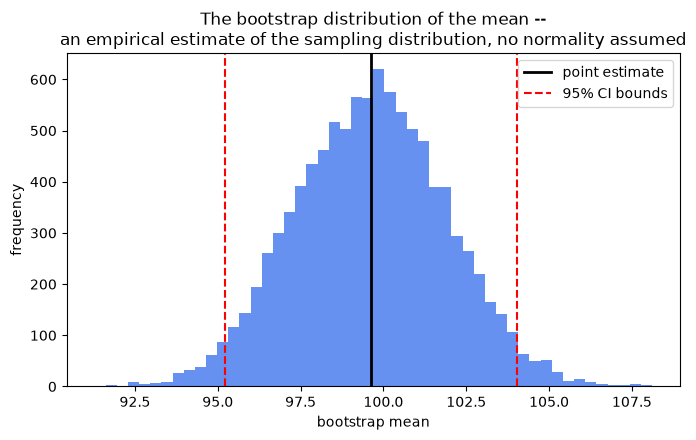

In [3]:
import matplotlib.pyplot as plt
from pathlib import Path
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(boot_dist, bins=50, color="#2563eb", alpha=0.7)
ax.axvline(point_estimate, color="black", linewidth=2, label="point estimate")
ax.axvline(lo, color="red", linestyle="--", label="95% CI bounds")
ax.axvline(hi, color="red", linestyle="--")
ax.set_xlabel("bootstrap mean"); ax.set_ylabel("frequency")
ax.set_title("The bootstrap distribution of the mean --\nan empirical estimate of the sampling distribution, no normality assumed")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "bootstrap_distribution.png", dpi=140)
plt.show()

## Part 3 - Permutation Test: an A/B Test, End to End (pp.112-123)

Simulate a real A/B test: control vs. treatment conversion, test via reshuffling group labels instead of a classical formula.

In [4]:
# simulate: control group converts at 10%, treatment (a genuine improvement) at 13%
n_control, n_treatment = 1000, 1000
control = rng.binomial(1, 0.10, size=n_control)
treatment = rng.binomial(1, 0.13, size=n_treatment)

observed_diff = treatment.mean() - control.mean()
print(f"observed conversion rates: control={control.mean():.4f}, treatment={treatment.mean():.4f}")
print(f"observed difference: {observed_diff:.4f}")

def permutation_test(group_a, group_b, n_perm=10000, random_state=0):
    rng = np.random.default_rng(random_state)
    pooled = np.concatenate([group_a, group_b])
    n_a = len(group_a)
    observed = group_b.mean() - group_a.mean()
    perm_diffs = np.empty(n_perm)
    for i in range(n_perm):
        shuffled = rng.permutation(pooled)          # reshuffle labels -- the permutation test's defining step
        perm_diffs[i] = shuffled[n_a:].mean() - shuffled[:n_a].mean()
    p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed))    # two-sided
    return observed, p_value, perm_diffs

observed, p_value, perm_diffs = permutation_test(control, treatment)
print(f"\npermutation test p-value: {p_value:.4f}")
print("interpretation: probability of seeing a difference this large or larger, BY CHANCE ALONE,")
print("if there were truly no difference between control and treatment (the null hypothesis).")

observed conversion rates: control=0.0800, treatment=0.1330
observed difference: 0.0530

permutation test p-value: 0.0002
interpretation: probability of seeing a difference this large or larger, BY CHANCE ALONE,
if there were truly no difference between control and treatment (the null hypothesis).


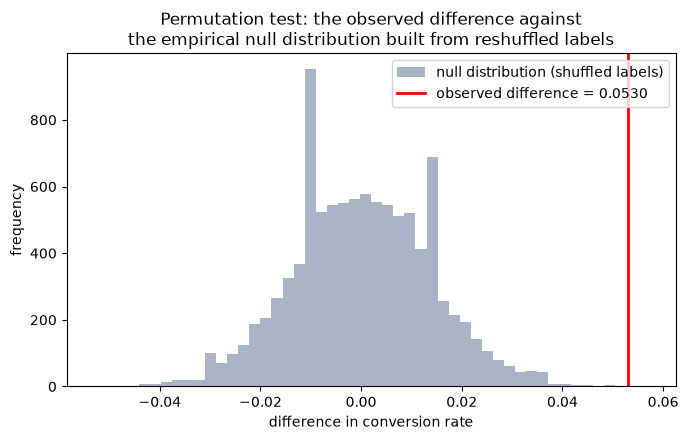

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(perm_diffs, bins=50, color="#94a3b8", alpha=0.8, label="null distribution (shuffled labels)")
ax.axvline(observed_diff, color="red", linewidth=2, label=f"observed difference = {observed_diff:.4f}")
ax.set_xlabel("difference in conversion rate"); ax.set_ylabel("frequency")
ax.set_title("Permutation test: the observed difference against\nthe empirical null distribution built from reshuffled labels")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "permutation_test.png", dpi=140)
plt.show()

## Part 4 - The Multiple Testing Problem, With an Actual Number (pp.132-136)

Run 20 independent tests where the null is ALWAYS true (no real effect anywhere) at alpha=0.05, and count how often at least one false positive appears purely by chance.

In [6]:
def simulate_multiple_testing(n_tests=20, alpha=0.05, n_simulations=5000, random_state=0):
    rng = np.random.default_rng(random_state)
    at_least_one_false_positive = 0
    for _ in range(n_simulations):
        # simulate n_tests independent p-values under a TRUE null (uniform on [0,1] is the null distribution of a p-value)
        p_values = rng.uniform(0, 1, size=n_tests)
        if np.any(p_values < alpha):
            at_least_one_false_positive += 1
    return at_least_one_false_positive / n_simulations

empirical_rate = simulate_multiple_testing()
theoretical_rate = 1 - (1 - 0.05)**20
print(f"empirical rate of >=1 false positive across 20 tests: {empirical_rate:.4f}")
print(f"theoretical rate (1 - 0.95^20):                        {theoretical_rate:.4f}")
print("\nEven with ZERO real effects anywhere, ~64% of the time at least one of 20 tests")
print("will show 'significance' by chance alone -- this is exactly why multiple-testing")
print("correction matters whenever many metrics or many experiments are compared at once.")

empirical rate of >=1 false positive across 20 tests: 0.6452
theoretical rate (1 - 0.95^20):                        0.6415

Even with ZERO real effects anywhere, ~64% of the time at least one of 20 tests
will show 'significance' by chance alone -- this is exactly why multiple-testing
correction matters whenever many metrics or many experiments are compared at once.


## Part 5 - Power and Sample Size (pp.156-161)

How many samples are needed to reliably (80% power) detect a true 3-percentage-point conversion lift?

In [7]:
from scipy import stats

def required_sample_size(p1, p2, alpha=0.05, power=0.80):
    # two-proportion z-test sample size formula
    z_alpha = stats.norm.ppf(1 - alpha/2)
    z_power = stats.norm.ppf(power)
    p_bar = (p1 + p2) / 2
    numerator = (z_alpha * np.sqrt(2*p_bar*(1-p_bar)) + z_power * np.sqrt(p1*(1-p1) + p2*(1-p2)))**2
    denominator = (p2 - p1)**2
    return int(np.ceil(numerator / denominator))

n_needed = required_sample_size(p1=0.10, p2=0.13)
print(f"samples needed PER GROUP to detect 10% -> 13% conversion lift, 80% power, alpha=0.05: {n_needed}")

# empirically verify via simulation: at this sample size, what fraction of simulated experiments
# correctly detect a significant difference (a rough proxy for power)?
def empirical_power(n_per_group, p1, p2, alpha=0.05, n_sims=2000, random_state=0):
    rng = np.random.default_rng(random_state)
    detections = 0
    for _ in range(n_sims):
        a = rng.binomial(1, p1, size=n_per_group)
        b = rng.binomial(1, p2, size=n_per_group)
        # a quick z-test for two proportions (not a full permutation test, for simulation speed)
        p_pool = (a.sum() + b.sum()) / (2*n_per_group)
        se = np.sqrt(2 * p_pool * (1-p_pool) / n_per_group)
        z = (b.mean() - a.mean()) / se if se > 0 else 0
        if abs(z) > stats.norm.ppf(1 - alpha/2):
            detections += 1
    return detections / n_sims

power_at_n = empirical_power(n_needed, 0.10, 0.13)
print(f"empirical power at n={n_needed} per group: {power_at_n:.3f}  (target was 0.80)")

samples needed PER GROUP to detect 10% -> 13% conversion lift, 80% power, alpha=0.05: 1774
empirical power at n=1774 per group: 0.786  (target was 0.80)


## Part 6 - Classification Evaluation: Confusion Matrix, Precision, Recall, ROC, AUC (pp.245-256)

In [8]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, roc_curve, roc_auc_score

# deliberately imbalanced: 95% negative, 5% positive
X, y = make_classification(n_samples=2000, n_features=10, weights=[0.95, 0.05], random_state=0)
model = LogisticRegression().fit(X, y)
probs = model.predict_proba(X)[:, 1]
preds = model.predict(X)

cm = confusion_matrix(y, preds)
print("confusion matrix:\n", cm)
print(f"precision: {precision_score(y, preds):.4f}")
print(f"recall:    {recall_score(y, preds):.4f}")
print(f"AUC:       {roc_auc_score(y, probs):.4f}")

# the accuracy trap: compare against a trivial always-majority-class baseline
trivial_preds = np.zeros_like(y)
trivial_accuracy = np.mean(trivial_preds == y)
model_accuracy = np.mean(preds == y)
print(f"\ntrivial always-negative baseline accuracy: {trivial_accuracy:.4f}  (catches ZERO positives)")
print(f"actual model accuracy:                     {model_accuracy:.4f}")
print("accuracy alone barely distinguishes these two very different models -- exactly why")
print("precision/recall/AUC are the metrics that matter on imbalanced data, not accuracy.")

confusion matrix:
 [[1892    0]
 [  12   96]]
precision: 1.0000
recall:    0.8889
AUC:       0.9588

trivial always-negative baseline accuracy: 0.9460  (catches ZERO positives)
actual model accuracy:                     0.9940
accuracy alone barely distinguishes these two very different models -- exactly why
precision/recall/AUC are the metrics that matter on imbalanced data, not accuracy.


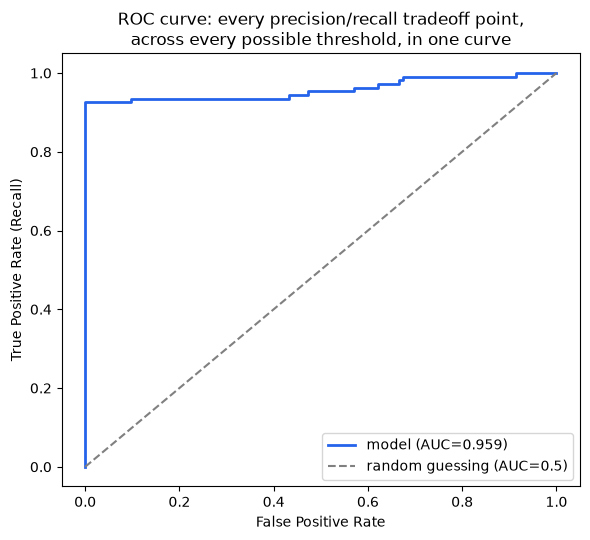

In [9]:
fpr, tpr, thresholds = roc_curve(y, probs)
auc = roc_auc_score(y, probs)

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot(fpr, tpr, color="#2563eb", linewidth=2, label=f"model (AUC={auc:.3f})")
ax.plot([0,1], [0,1], color="gray", linestyle="--", label="random guessing (AUC=0.5)")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC curve: every precision/recall tradeoff point,\nacross every possible threshold, in one curve")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "roc_curve.png", dpi=140)
plt.show()